Coherence estimate using nuclear radius R = R0 * A^(1/3) with R0 = 1.2 fm
Target   A  Radius R [fm]  Coherence Energy [MeV]
    He   4           1.90                   103.4
     C  12           2.75                    71.7
     F  19           3.20                    61.5
     S  32           3.81                    51.7
    Ar  40           4.10                    48.0
    Ge  73           5.02                    39.3
     I 127           6.03                    32.7
    Cs 133           6.13                    32.2


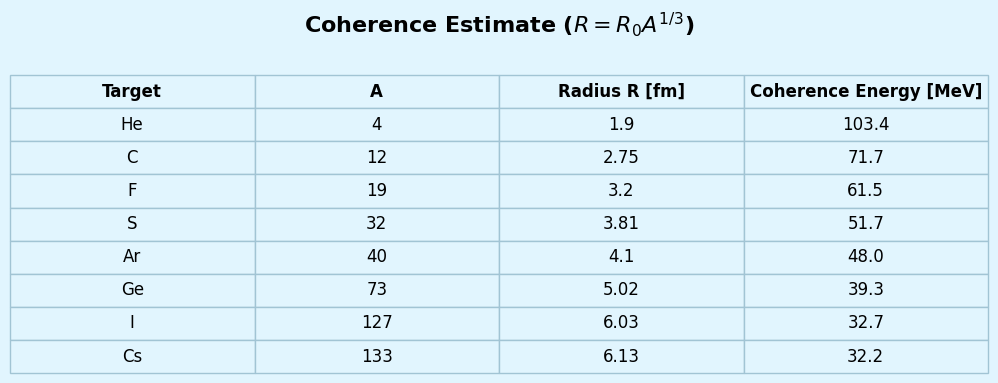

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Nuclear radius parameter
R0 = 1.2  # fm

# Targets and mass numbers
targets = {
    "He": 4,
    "C": 12,
    "F": 19,
    "S": 32,
    "Ar": 40,
    "Ge": 73,
    "I": 127,
    "Cs": 133
}

rows = []

for target, A in targets.items():
    R = R0 * A**(1/3)
    Ecoh = 197 / R  # MeV (using 1 fm^-1 = 197 MeV)
    
    rows.append({
        "Target": target,
        "A": A,
        "Radius R [fm]": round(R,2),
        "Coherence Energy [MeV]": round(Ecoh,1)
    })

df = pd.DataFrame(rows)

print("Coherence estimate using nuclear radius R = R0 * A^(1/3) with R0 = 1.2 fm")
print(df.to_string(index=False))

import matplotlib.pyplot as plt
import pandas as pd

# Assuming your df looks something like this:
# df = pd.DataFrame({
#     "Isotope": ["C-12", "Al-27", "Fe-56", "Ag-108", "Pb-208"],
#     "A": [12, 27, 56, 108, 208],
#     "Radius (fm)": [2.75, 3.60, 4.59, 5.71, 7.11]
# })

def plot_styled_table(df):
    # Define colors
    bg_color = '#e1f5fe'  # A crisp, light blue
    text_color = '#000000' # Pure black for high contrast
    
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(bg_color)
    ax.axis('off')

    # Create the table
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )

    # Styling the table elements
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2.5) # Scale height and width for readability

    for key, cell in table.get_celld().items():
        cell.set_facecolor(bg_color)
        cell.set_edgecolor('#a1c4d4') # Slightly darker blue for subtle borders
        cell.get_text().set_color(text_color)
        cell.get_text().set_weight('medium')
        
        # Make the header bold
        if key[0] == 0:
            cell.get_text().set_weight('bold')

    plt.title("Coherence Estimate ($R = R_0 A^{1/3}$)", 
              fontsize=16, pad=50, color=text_color, weight='bold')
    
    plt.tight_layout()
    plt.show()

# Execute the plot
plot_styled_table(df)



In [15]:
# Cell 1
# Imports and plotting style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gamma

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [24]:
# Cell 2
# Physical constants and paper benchmark numbers
#
# Paper ingredients used here:
# - SNS flux model: Eq. (1)-(2)
# - CEvNS differential cross section: Eq. (3)
# - Helm form factor: Eq. (4)
# - 1 m^3 benchmark gas: 60:40 He:CF4, 1 atm, 293 K
# - Paper target masses in 1 m^3: (He, C, F) = (0.1, 0.2, 1.26) kg
#
# This notebook reproduces the paper's non-directional rate estimate,
# then swaps the SNS source for a supernova fluence.

# Fundamental constants
NA = 6.02214076e23               # mol^-1
HBARC = 197.3269804              # MeV fm
GF = 2.3016e-22                  # cm MeV^-1  (paper convention)
SIN2_THETA_W = 0.2387            # paper value
MEV_PER_ERG = 6.241509074e5      # MeV / erg

# Masses
m_mu = 105.65                    # MeV
m_pi = 139.57                    # MeV
amu_MeV = 931.49410242           # MeV

# Paper SNS normalization
r_pi_per_POT = 0.087
nPOT_per_year = 1.728e23
L_sns_m = 12.0
L_sns_cm = L_sns_m * 100.0

# Targets in the paper gas
targets = {
    "He": {"A": 4,  "Z": 2, "R_rms_fm": 1.6755},
    "C":  {"A": 12, "Z": 6, "R_rms_fm": 2.4702},
    "F":  {"A": 19, "Z": 9, "R_rms_fm": 2.8976},
}

# Paper benchmark target masses in 1 m^3
paper_masses_1m3_kg = {"He": 0.10, "C": 0.20, "F": 1.26} # The paper tells us at atm pressure we have these masses of each element in 1 m^3.

# Detector list: use paper masses scaled by active volume
# This keeps the gas assumptions fixed across all detectors for apples-to-apples comparison.
detectors = {
    "Paper 1 m$^3$": {
        "volume_m3": 1.0,
        "dimensions": "conceptual paper benchmark",
    },
    "Paper 10 m$^3$": {
        "volume_m3": 10.0,
        "dimensions": r"10 m^3 conceptual paper benchmark",
    },
    "LIME": {
        "volume_m3": 0.050,   # 50 L
        "dimensions": "",
    },
    "CYGNO-04": {
        "volume_m3": 0.400,   # 0.4 m^3
        "dimensions": "",
    },
}

for det in detectors.values():
    scale = det["volume_m3"] / 1.0
    det["masses_kg"] = {k: scale * v for k, v in paper_masses_1m3_kg.items()}
    det["total_mass_kg"] = sum(det["masses_kg"].values())

# Print a detector summary table
rows = []
for name, det in detectors.items():
    rows.append({
        "Detector": name,
        "Dimensions / note": det["dimensions"],
        "Volume [m^3]": det["volume_m3"],
        "He mass [kg]": det["masses_kg"]["He"],
        "C mass [kg]": det["masses_kg"]["C"],
        "F mass [kg]": det["masses_kg"]["F"],
        "Total gas mass [kg]": det["total_mass_kg"],
    })

detector_df = pd.DataFrame(rows)
print(detector_df.to_string(index=False))

      Detector                 Dimensions / note  Volume [m^3]  He mass [kg]  C mass [kg]  F mass [kg]  Total gas mass [kg]
 Paper 1 m$^3$        conceptual paper benchmark          1.00         0.100         0.20        1.260                1.560
Paper 10 m$^3$ 10 m^3 conceptual paper benchmark         10.00         1.000         2.00       12.600               15.600
          LIME                                            0.05         0.005         0.01        0.063                0.078
      CYGNO-04                                            0.40         0.040         0.08        0.504                0.624


In [25]:
# Cell 3
# Nuclear helper functions: target counts, vector coupling, Helm form factor

def spherical_bessel_j1(x):
    """
    j1(x) = sin(x)/x^2 - cos(x)/x
    Safe near x = 0.
    """
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    small = np.abs(x) < 1e-6
    large = ~small
    out[small] = x[small] / 3.0
    out[large] = np.sin(x[large]) / x[large]**2 - np.cos(x[large]) / x[large]
    return out

def helm_form_factor(q_MeV, R_rms_fm):
    """
    Helm form factor used in the paper.
    q in MeV, radii in fm.
    """
    s = 0.9  # fm
    rn = np.sqrt((5.0 / 3.0) * (R_rms_fm**2 - 3.0 * s**2))
    x = q_MeV * rn / HBARC
    qs = q_MeV * s / HBARC

    F = np.ones_like(q_MeV, dtype=float)
    nonzero = np.abs(x) > 1e-10
    F[nonzero] = 3.0 * spherical_bessel_j1(x[nonzero]) / x[nonzero] * np.exp(-0.5 * qs[nonzero]**2)
    return F

def nuclear_vector_coupling(Z, A, sin2thetaW=SIN2_THETA_W):
    N = A - Z
    gVp = 0.5 - 2.0 * sin2thetaW
    gVn = -0.5
    return Z * gVp + N * gVn

def target_nuclei_count(mass_kg, A):
    """
    Number of target nuclei from elemental mass.
    """
    mass_g = mass_kg * 1e3
    return mass_g / A * NA

def d_sigma_dEr_cm2_per_MeV(E_nu_MeV, E_r_keV, A, Z, R_rms_fm):
    """
    CEvNS differential cross section from the paper, Eq. (3).
    Returns cm^2 / MeV.
    E_nu in MeV, E_r in keV_r.
    """
    E_nu = np.asarray(E_nu_MeV, dtype=float)
    E_r = np.asarray(E_r_keV, dtype=float) / 1e3  # keV -> MeV
    mN = A * amu_MeV
    q = np.sqrt(2.0 * mN * E_r)  # MeV
    F = helm_form_factor(q, R_rms_fm)
    gV = nuclear_vector_coupling(Z, A)

    kin = 1.0 - (mN * E_r) / (2.0 * E_nu**2)
    kin = np.clip(kin, 0.0, None)

    return (GF**2 * mN / np.pi) * (F**2) * (gV**2) * kin

In [26]:
# Cell 4
# SNS source model from the paper, Eq. (1)-(2)

E_prompt_MeV = (m_pi**2 - m_mu**2) / (2.0 * m_pi)

# Common yearly fluence normalization per neutrino flavor at the detector
sns_norm_per_cm2_per_year = r_pi_per_POT * nPOT_per_year / (4.0 * np.pi * L_sns_cm**2) #Normalizzazione di Eq (2)

def F_nue_shape(E):
    """
    Paper Eq. (1), normalized shape for delayed nu_e.
    """
    E = np.asarray(E)
    out = np.zeros_like(E, dtype=float)
    mask = (E >= 0.0) & (E <= m_mu / 2.0)
    x = E[mask] / m_mu
    out[mask] = (192.0 / m_mu) * x**2 * (0.5 - x)
    return out

def F_numubar_shape(E):
    """
    Paper Eq. (1), normalized shape for delayed anti-nu_mu.
    """
    E = np.asarray(E)
    out = np.zeros_like(E, dtype=float)
    mask = (E >= 0.0) & (E <= m_mu / 2.0)
    x = E[mask] / m_mu
    out[mask] = (64.0 / m_mu) * x**2 * (0.75 - x)
    return out

def sns_flux_continuous_per_MeV_per_cm2_per_year(E):
    """
    Total continuous SNS flux = delayed nu_e + delayed anti-nu_mu.
    """
    return sns_norm_per_cm2_per_year * (F_nue_shape(E) + F_numubar_shape(E))

def sns_prompt_line_fluence_per_cm2_per_year():
    """
    Prompt monoenergetic nu_mu yearly fluence at 29.8 MeV.
    """
    return sns_norm_per_cm2_per_year

# Quick normalization checks
E_test = np.linspace(0, m_mu / 2.0, 5000)
print("Integral F_nue dE      =", np.trapz(F_nue_shape(E_test), E_test))
print("Integral F_numubar dE  =", np.trapz(F_numubar_shape(E_test), E_test))
print("Prompt line energy [MeV] =", E_prompt_MeV)
print("Per-flavor SNS yearly fluence [cm^-2 year^-1] =", sns_norm_per_cm2_per_year)

Integral F_nue dE      = 0.9999999599839953
Integral F_numubar dE  = 1.0
Prompt line energy [MeV] = 29.798174392777813
Per-flavor SNS yearly fluence [cm^-2 year^-1] = 830788802939693.6


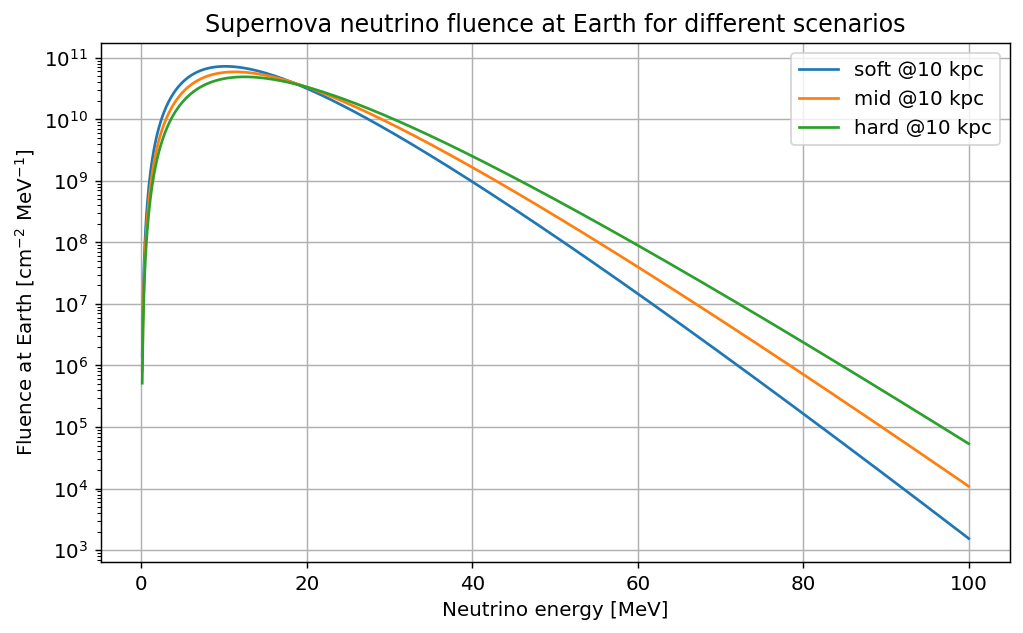

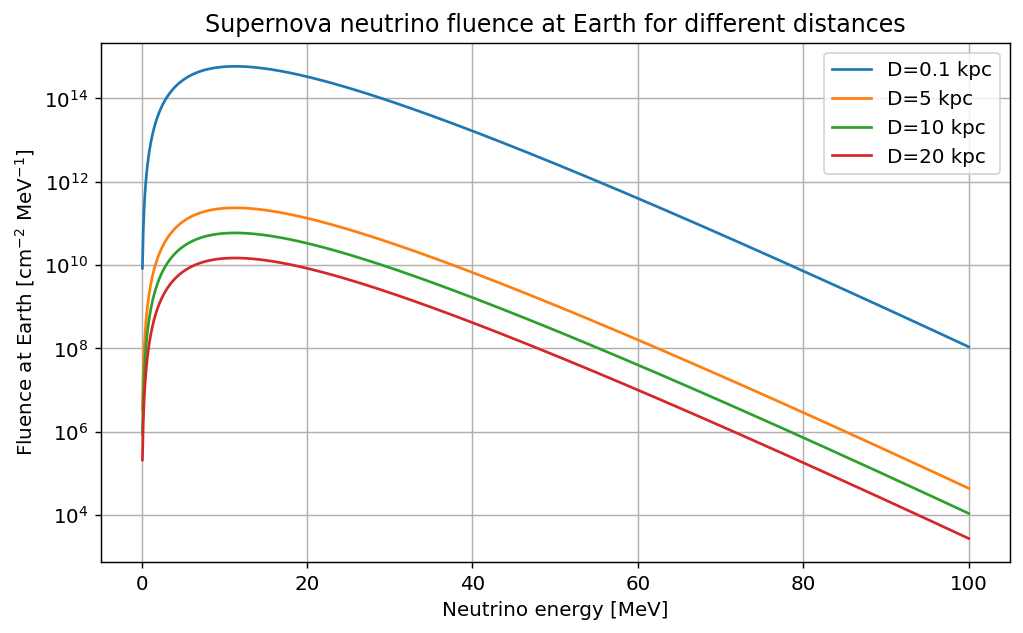

In [42]:
# Cell 5
# Supernova source model:
# Pinched thermal fluence for one burst at Earth.
#
# Benchmarks:
# - canonical total neutrino energy: 3e53 erg
# - equal partition across 6 species
# - average energies in realistic ranges:
#   <E_nue> = 12-15 MeV, <E_anue> = 12-15 MeV, <E_nux> = 15-18 MeV
#
# Since CEvNS is flavor blind, we sum:
#   nu_e + anti_nu_e + 4 * nu_x

def pinched_spectrum(E, Eavg, alpha=3.0):
    """
    Normalized gamma-like / pinched spectrum:
    integral dE f(E) = 1
    """
    E = np.asarray(E, dtype=float)
    c = (alpha + 1.0)**(alpha + 1.0) / (gamma(alpha + 1.0) * Eavg**(alpha + 1.0))
    return c * E**alpha * np.exp(-(alpha + 1.0) * E / Eavg)

def sn_fluence_total_per_MeV_per_cm2(
    E,
    D_kpc=10.0,
    E_total_erg=3e53,
    Eavg_nue=12.0,
    Eavg_anue=12.0,
    Eavg_nux=15.0,
    alpha=3.0,
):
    """
    Total all-flavor time-integrated fluence at Earth for one supernova burst.
    Equal partition among 6 species.
    """
    D_cm = D_kpc * 3.085677581e21
    E_flavor_erg = E_total_erg / 6.0
    E_flavor_MeV = E_flavor_erg * MEV_PER_ERG

    def one_flavor_fluence(E, Eavg):
        N_nu = E_flavor_MeV / Eavg
        return N_nu * pinched_spectrum(E, Eavg, alpha=alpha) / (4.0 * np.pi * D_cm**2)

    return (
        one_flavor_fluence(E, Eavg_nue)
        + one_flavor_fluence(E, Eavg_anue)
        + 4.0 * one_flavor_fluence(E, Eavg_nux)
    )

# A few realistic benchmark SN scenarios
sn_scenarios = {
    "soft @10 kpc": {
        "D_kpc": 10.0, "E_total_erg": 3e53,
        "Eavg_nue": 12.0, "Eavg_anue": 12.0, "Eavg_nux": 15.0, "alpha": 3.0
    },
    "mid @10 kpc": {
        "D_kpc": 10.0, "E_total_erg": 3e53,
        "Eavg_nue": 13.5, "Eavg_anue": 13.5, "Eavg_nux": 16.5, "alpha": 3.0
    },
    "hard @10 kpc": {
        "D_kpc": 10.0, "E_total_erg": 3e53,
        "Eavg_nue": 15.0, "Eavg_anue": 15.0, "Eavg_nux": 18.0, "alpha": 3.0
    },
}

# Also prepare distance scan at fixed "mid" spectrum
sn_distance_list_kpc = [0.1, 5, 10, 20]


#PLot the considered SN spectrum for 3 distances at fixed Eavg
E_sn_MeV = np.linspace(0.1, 100.0, 1000)
plt.figure(figsize=(8,5))
for name, params in sn_scenarios.items():
    fluence = sn_fluence_total_per_MeV_per_cm2(E_sn_MeV, **params)
    plt.plot(E_sn_MeV, fluence, label=name)
plt.xlabel("Neutrino energy [MeV]")
plt.ylabel("Fluence at Earth [cm$^{-2}$ MeV$^{-1}$]")
plt.title("Supernova neutrino fluence at Earth for different scenarios")

plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# SAme as above but at 0.1 Kpc to show the effect of distance
E_sn_MeV = np.linspace(0.1, 100.0, 1000)
plt.figure(figsize=(8,5))
for D_kpc in sn_distance_list_kpc:
    params = sn_scenarios["mid @10 kpc"].copy()
    params["D_kpc"] = D_kpc
    fluence = sn_fluence_total_per_MeV_per_cm2(E_sn_MeV, **params)
    plt.plot(E_sn_MeV, fluence, label=f"D={D_kpc} kpc")
plt.xlabel("Neutrino energy [MeV]")
plt.ylabel("Fluence at Earth [cm$^{-2}$ MeV$^{-1}$]")
plt.title("Supernova neutrino fluence at Earth for different distances")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Cell 6
# Generic event-rate engine
#
# It computes dR/dEr for one target, given either:
# - SNS yearly flux
# - SN burst fluence
#
# Then we can integrate above threshold to get total counts.

def E_nu_min_MeV(E_r_keV, A):
    """
    Minimum neutrino energy that can produce recoil E_r:
    E_nu,min = sqrt(m_N E_r / 2)
    """
    mN = A * amu_MeV
    E_r_MeV = np.asarray(E_r_keV) / 1e3
    return np.sqrt(mN * E_r_MeV / 2.0)

def differential_rate_target(
    E_r_keV_grid,
    source="SNS",
    detector_name="Paper 1 m$^3$",
    target_name="F",
    sn_params=None,
    include_prompt=True,
):
    """
    Returns dN/dEr in units:
    - events / year / keV_r for SNS
    - events / burst / keV_r for SN
    """
    info = targets[target_name]
    A, Z, R_rms_fm = info["A"], info["Z"], info["R_rms_fm"]
    N_targets = target_nuclei_count(detectors[detector_name]["masses_kg"][target_name], A)

    E_r_keV_grid = np.asarray(E_r_keV_grid, dtype=float)
    # Avendo un insime di recoil energies, calcoliamo per ciascuno l'energia minima del neutrino che può produrlo
    # questo è il lower limit dell'integrale in energia
    Emin = E_nu_min_MeV(E_r_keV_grid, A)
    #Nota che non integriamo sulla recoil energy questo è a tutti gli effetti un parametro

    # Continuous energy grid
    #Griglia su cui integriamo da 0.01 a 80 MeV, con 3000 punti, è l'energia del neutrino
    #Dopo imporremo Emin come lower limit dell'integrale
    E_nu_grid = np.linspace(0.01, 80.0, 3000)

    if source.upper() == "SNS":
        phi_cont = sns_flux_continuous_per_MeV_per_cm2_per_year(E_nu_grid)
    elif source.upper() == "SN":
        phi_cont = sn_fluence_total_per_MeV_per_cm2(E_nu_grid, **sn_params)
    else:
        raise ValueError("source must be 'SNS' or 'SN'")

    # Continuous part
    dsig = d_sigma_dEr_cm2_per_MeV(
        E_nu_grid[None, :],
        E_r_keV_grid[:, None],
        A=A, Z=Z, R_rms_fm=R_rms_fm,
    )

    mask = E_nu_grid[None, :] >= Emin[:, None] 
    cont = N_targets * np.trapz(dsig * phi_cont[None, :] * mask, E_nu_grid, axis=1) / 1e3
    # divide by 1e3 to convert d/d(MeV_r) to d/d(keV_r)

    # Prompt SNS line
    line = np.zeros_like(E_r_keV_grid)
    if source.upper() == "SNS" and include_prompt:
        allowed = E_prompt_MeV >= Emin
        dsig_line = d_sigma_dEr_cm2_per_MeV(
            np.full_like(E_r_keV_grid, E_prompt_MeV),
            E_r_keV_grid,
            A=A, Z=Z, R_rms_fm=R_rms_fm,
        )
        line = N_targets * sns_prompt_line_fluence_per_cm2_per_year() * dsig_line * allowed / 1e3

    return cont + line

def integrated_counts_above_threshold(
    E_threshold_keV,
    source="SNS",
    detector_name="Paper 1 m$^3$",
    target_name="F",
    sn_params=None,
):
    E_r = np.linspace(E_threshold_keV, 1500.0, 3000)
    dNdEr = differential_rate_target(
        E_r, source=source, detector_name=detector_name, target_name=target_name, sn_params=sn_params
    )
    return np.trapz(dNdEr, E_r)

def integrated_counts_all_targets(
    E_threshold_keV,
    source="SNS",
    detector_name="Paper 1 m$^3$",
    sn_params=None,
):
    out = {}
    total = 0.0
    for t in targets:
        n = integrated_counts_above_threshold(
            E_threshold_keV, source=source, detector_name=detector_name, target_name=t, sn_params=sn_params
        )
        out[t] = n
        total += n
    out["Total"] = total
    return out

SNS, Paper 1 m^3, counts above 10 keV_r
   He: 0.62
    C: 3.27
    F: 32.86
Total: 36.76


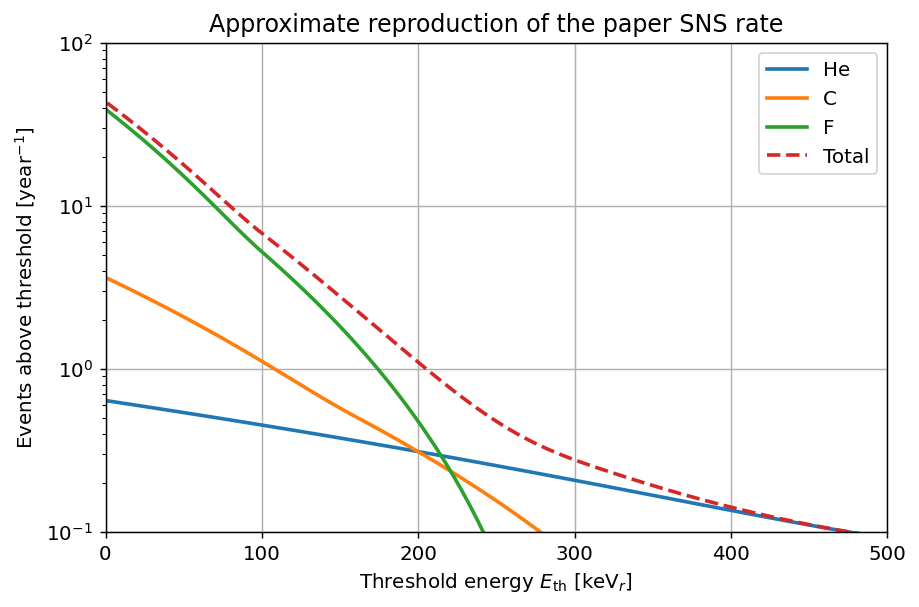

In [32]:
# Cell 7
# Reproduce the paper's Fig. 2 left approximately:
# events above threshold in the 1 m^3 paper detector at SNS

Eth_grid = np.linspace(1.0, 500.0, 100)

sns_threshold_curves = {t: [] for t in ["He", "C", "F", "Total"]}

for Eth in Eth_grid:
    counts = integrated_counts_all_targets(Eth, source="SNS", detector_name="Paper 1 m$^3$")
    for key in sns_threshold_curves:
        sns_threshold_curves[key].append(counts[key])

sns_check_10keV = integrated_counts_all_targets(10.0, source="SNS", detector_name="Paper 1 m$^3$")
print("SNS, Paper 1 m^3, counts above 10 keV_r")
for k, v in sns_check_10keV.items():
    print(f"{k:>5s}: {v:.2f}")

plt.figure(figsize=(7.2, 4.8))
for key, ls in zip(["He", "C", "F", "Total"], ["-", "-", "-", "--"]):
    plt.plot(Eth_grid, sns_threshold_curves[key], lw=2, ls=ls, label=key)

plt.yscale("log")
plt.xlabel(r"Threshold energy $E_{\rm th}$ [keV$_r$]")
plt.ylabel("Events above threshold [year$^{-1}$]")
plt.title("Approximate reproduction of the paper SNS rate")
plt.ylim(1e-1,1e2)
plt.xlim(0,500)
plt.legend()
plt.tight_layout()
plt.show()

Prompt-only SNS events above 10 keV_r
      Detector  Prompt He / year  Prompt C / year  Prompt F / year  Prompt total / year
 Paper 1 m$^3$          0.158886         0.839520         8.374066             9.372472
Paper 10 m$^3$          1.588861         8.395203        83.740656            93.724719
          LIME          0.007944         0.041976         0.418703             0.468624
      CYGNO-04          0.063554         0.335808         3.349626             3.748989


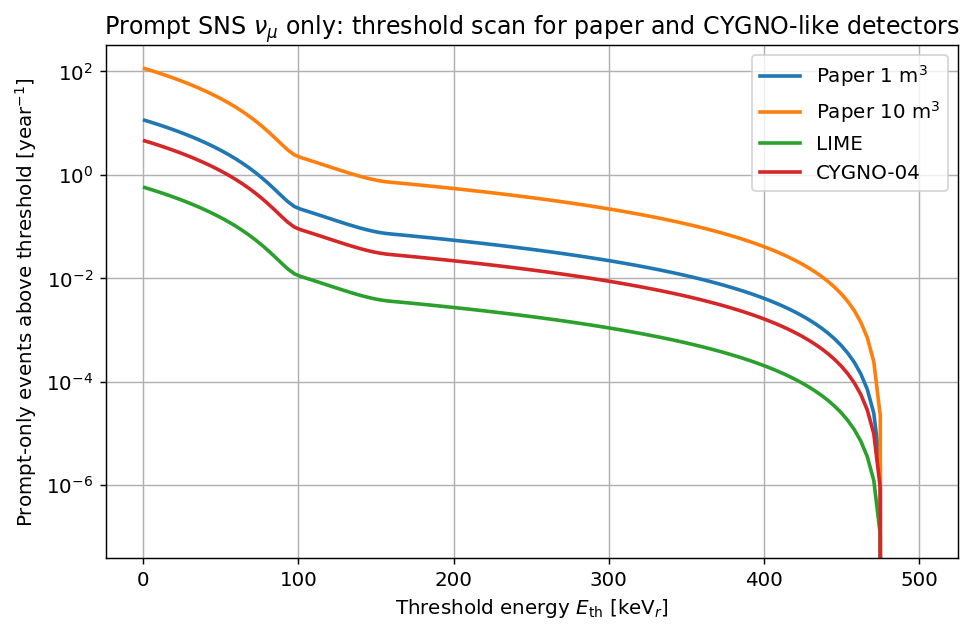

In [63]:
# Cell 7.5
# Fig. 2-left style threshold scan, but:
# - compare Paper 1 m^3, Paper 10 m^3, LIME, CYGNO-04
# - include ONLY the prompt SNS nu_mu line at E_prompt ~ 29.8 MeV

def differential_rate_target_prompt_only(E_r_keV_grid, detector_name="Paper 1 m$^3$", target_name="F"):
    """
    Prompt-only SNS recoil spectrum dN/dEr for one target.
    Units: events / year / keV_r
    """
    info = targets[target_name]
    A, Z, R_rms_fm = info["A"], info["Z"], info["R_rms_fm"]
    N_targets = target_nuclei_count(detectors[detector_name]["masses_kg"][target_name], A)

    E_r_keV_grid = np.asarray(E_r_keV_grid, dtype=float)
    Emin = E_nu_min_MeV(E_r_keV_grid, A)

    # Only recoils kinematically allowed for the prompt 29.8 MeV neutrino
    allowed = E_prompt_MeV >= Emin

    dsig_line = d_sigma_dEr_cm2_per_MeV(
        np.full_like(E_r_keV_grid, E_prompt_MeV),
        E_r_keV_grid,
        A=A, Z=Z, R_rms_fm=R_rms_fm,
    )

    # Convert from per MeV_r to per keV_r
    return N_targets * sns_prompt_line_fluence_per_cm2_per_year() * dsig_line * allowed / 1e3


def integrated_counts_above_threshold_prompt_only(E_threshold_keV, detector_name="Paper 1 m$^3$", target_name="F"):
    E_r = np.linspace(E_threshold_keV, 1500.0, 3000)
    dNdEr = differential_rate_target_prompt_only(E_r, detector_name=detector_name, target_name=target_name)
    return np.trapz(dNdEr, E_r)


def integrated_counts_all_targets_prompt_only(E_threshold_keV, detector_name="Paper 1 m$^3$"):
    out = {}
    total = 0.0
    for t in targets:
        n = integrated_counts_above_threshold_prompt_only(E_threshold_keV, detector_name=detector_name, target_name=t)
        out[t] = n
        total += n
    out["Total"] = total
    return out


# Threshold scan
Eth_grid = np.linspace(1.0, 500.0, 120)
detector_order = ["Paper 1 m$^3$", "Paper 10 m$^3$", "LIME", "CYGNO-04"]

prompt_curves = {}
for det_name in detector_order:
    prompt_curves[det_name] = []
    for Eth in Eth_grid:
        counts = integrated_counts_all_targets_prompt_only(Eth, detector_name=det_name)
        prompt_curves[det_name].append(counts["Total"])

# Print a compact table at the paper benchmark threshold
rows = []
for det_name in detector_order:
    counts_10 = integrated_counts_all_targets_prompt_only(10.0, detector_name=det_name)
    rows.append({
        "Detector": det_name,
        "Prompt He / year": counts_10["He"],
        "Prompt C / year": counts_10["C"],
        "Prompt F / year": counts_10["F"],
        "Prompt total / year": counts_10["Total"],
    })

prompt_df = pd.DataFrame(rows)
print("Prompt-only SNS events above 10 keV_r")
print(prompt_df.to_string(index=False))

# Plot
plt.figure(figsize=(7.6, 5.0))
for det_name in detector_order:
    plt.plot(Eth_grid, prompt_curves[det_name], lw=2, label=det_name)

plt.yscale("log")
plt.xlabel(r"Threshold energy $E_{\rm th}$ [keV$_r$]")
plt.ylabel("Prompt-only events above threshold [year$^{-1}$]")
plt.title(r"Prompt SNS $\nu_\mu$ only: threshold scan for paper and CYGNO-like detectors")
plt.legend()
plt.tight_layout()
plt.show()

Delayed-only SNS events above 10 keV_r
      Detector  Delayed He / year  Delayed C / year  Delayed F / year  Delayed total / year
 Paper 1 m$^3$           0.460659          2.434703         24.488529             27.383892
Paper 10 m$^3$           4.606591         24.347031        244.885294            273.838916
          LIME           0.023033          0.121735          1.224426              1.369195
      CYGNO-04           0.184264          0.973881          9.795412             10.953557


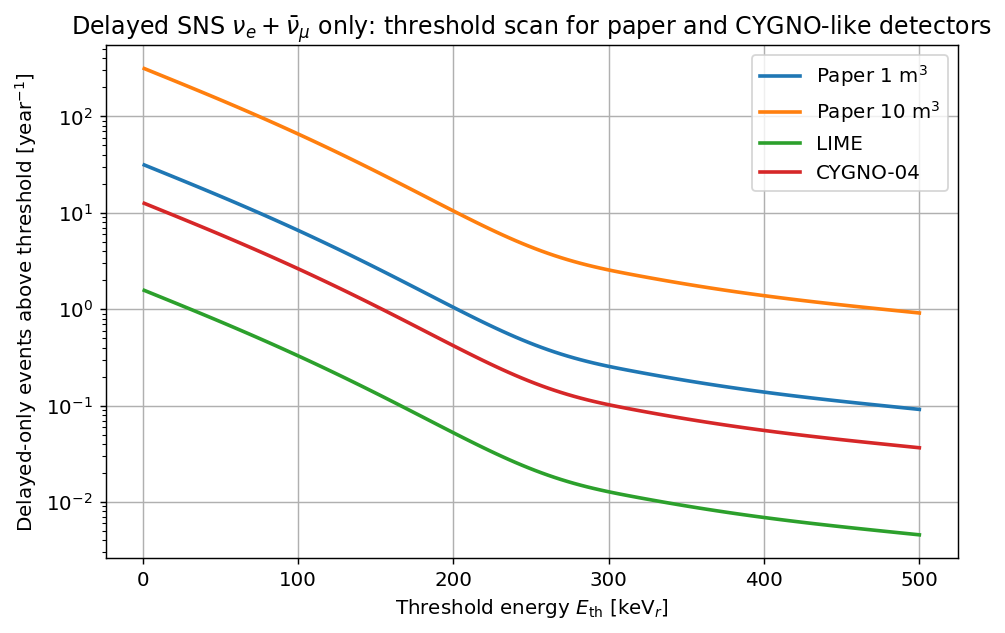

In [72]:
# Cell 7.8
# Fig. 2-left style threshold scan, but:
# - compare Paper 1 m^3, Paper 10 m^3, LIME, CYGNO-04
# - include ONLY the delayed SNS components: nu_e + anti-nu_mu
#   (exclude the prompt monoenergetic nu_mu line)

def differential_rate_target_delayed_only(E_r_keV_grid, detector_name="Paper 1 m$^3$", target_name="F"):
    """
    Delayed-only SNS recoil spectrum dN/dEr for one target.
    Units: events / year / keV_r
    Includes only:
      - delayed nu_e
      - delayed anti-nu_mu
    Excludes:
      - prompt monoenergetic nu_mu
    """
    info = targets[target_name]
    A, Z, R_rms_fm = info["A"], info["Z"], info["R_rms_fm"]
    N_targets = target_nuclei_count(detectors[detector_name]["masses_kg"][target_name], A)

    E_r_keV_grid = np.asarray(E_r_keV_grid, dtype=float)
    Emin = E_nu_min_MeV(E_r_keV_grid, A)

    # Delayed SNS neutrino-energy grid
    # The delayed spectra vanish above m_mu/2 ~ 52.8 MeV, but 80 MeV is harmless.
    E_nu_grid = np.linspace(0.01, 80.0, 3000)
    phi_delayed = sns_flux_continuous_per_MeV_per_cm2_per_year(E_nu_grid)

    # CEvNS differential cross section on the 2D grid (Er, Enu)
    dsig = d_sigma_dEr_cm2_per_MeV(
        E_nu_grid[None, :],
        E_r_keV_grid[:, None],
        A=A, Z=Z, R_rms_fm=R_rms_fm,
    )

    # Enforce the kinematic lower limit E_nu >= E_nu,min(Er)
    mask = E_nu_grid[None, :] >= Emin[:, None]

    # Integrate over delayed neutrino energy only
    dNdEr = N_targets * np.trapz(dsig * phi_delayed[None, :] * mask, E_nu_grid, axis=1) / 1e3
    return dNdEr


def integrated_counts_above_threshold_delayed_only(E_threshold_keV, detector_name="Paper 1 m$^3$", target_name="F"):
    E_r = np.linspace(E_threshold_keV, 1500.0, 3000)
    dNdEr = differential_rate_target_delayed_only(E_r, detector_name=detector_name, target_name=target_name)
    return np.trapz(dNdEr, E_r)


def integrated_counts_all_targets_delayed_only(E_threshold_keV, detector_name="Paper 1 m$^3$"):
    out = {}
    total = 0.0
    for t in targets:
        n = integrated_counts_above_threshold_delayed_only(E_threshold_keV, detector_name=detector_name, target_name=t)
        out[t] = n
        total += n
    out["Total"] = total
    return out


# Threshold scan
Eth_grid = np.linspace(1.0, 500.0, 120)
detector_order = ["Paper 1 m$^3$", "Paper 10 m$^3$", "LIME", "CYGNO-04"]

delayed_curves = {}
for det_name in detector_order:
    delayed_curves[det_name] = []
    for Eth in Eth_grid:
        counts = integrated_counts_all_targets_delayed_only(Eth, detector_name=det_name)
        delayed_curves[det_name].append(counts["Total"])

# Print a compact table at the paper benchmark threshold
rows = []
for det_name in detector_order:
    counts_10 = integrated_counts_all_targets_delayed_only(10.0, detector_name=det_name)
    rows.append({
        "Detector": det_name,
        "Delayed He / year": counts_10["He"],
        "Delayed C / year": counts_10["C"],
        "Delayed F / year": counts_10["F"],
        "Delayed total / year": counts_10["Total"],
    })

delayed_df = pd.DataFrame(rows)
print("Delayed-only SNS events above 10 keV_r")
print(delayed_df.to_string(index=False))

# Plot
plt.figure(figsize=(7.6, 5.0))
for det_name in detector_order:
    plt.plot(Eth_grid, delayed_curves[det_name], lw=2, label=det_name)

plt.yscale("log")
plt.xlabel(r"Threshold energy $E_{\rm th}$ [keV$_r$]")
plt.ylabel("Delayed-only events above threshold [year$^{-1}$]")
plt.title(r"Delayed SNS $\nu_e + \bar{\nu}_\mu$ only: threshold scan for paper and CYGNO-like detectors")
plt.legend()
plt.tight_layout()
plt.show()

Full SNS CEvNS events above 10 keV_r
      Detector  He / year  C / year   F / year  Total / year
 Paper 1 m$^3$   0.619545  3.274223  32.862595     36.756364
Paper 10 m$^3$   6.195451 32.742234 328.625950    367.563635
          LIME   0.030977  0.163711   1.643130      1.837818
      CYGNO-04   0.247818  1.309689  13.145038     14.702545


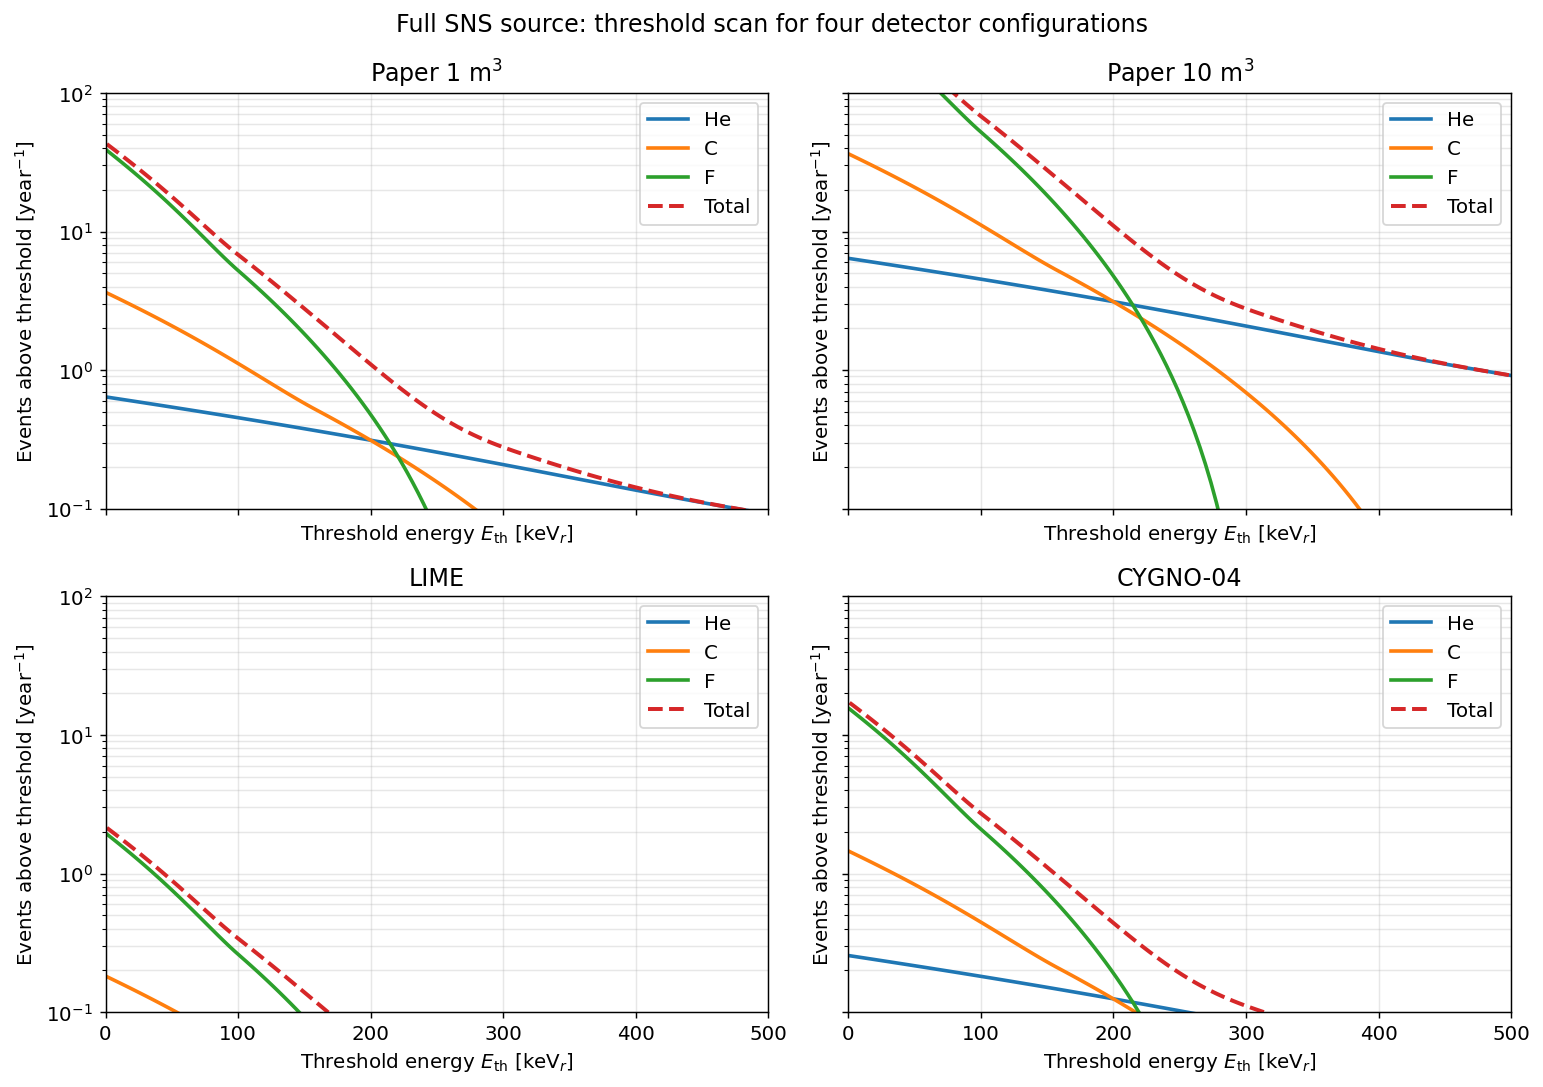

In [48]:
# Cell 7.1 (modified)
# Fig. 2-left style threshold scan for four detector configurations:
# - Paper 1 m^3   (paper reproduction benchmark)
# - Paper 10 m^3
# - LIME
# - CYGNO-04
#
# Uses the full SNS source:
# prompt nu_mu + delayed nu_e + delayed anti-nu_mu
#
# For each detector, plot:
# - He contribution
# - C contribution
# - F contribution
# - Total contribution
#
# It also prints the event numbers above 10 keV_r.

Eth_grid = np.linspace(1.0, 500.0, 120)
detector_order = ["Paper 1 m$^3$", "Paper 10 m$^3$", "LIME", "CYGNO-04"]

# Compute threshold curves for each detector and each target
full_sns_curves = {}
for det_name in detector_order:
    full_sns_curves[det_name] = {"He": [], "C": [], "F": [], "Total": []}
    for Eth in Eth_grid:
        counts = integrated_counts_all_targets(
            Eth,
            source="SNS",
            detector_name=det_name
        )
        for key in ["He", "C", "F", "Total"]:
            full_sns_curves[det_name][key].append(counts[key])

# Print totals at the paper benchmark threshold E_th = 10 keV_r
rows = []
for det_name in detector_order:
    counts_10 = integrated_counts_all_targets(
        10.0,
        source="SNS",
        detector_name=det_name
    )
    rows.append({
        "Detector": det_name,
        "He / year": counts_10["He"],
        "C / year": counts_10["C"],
        "F / year": counts_10["F"],
        "Total / year": counts_10["Total"],
    })

sns_detector_df = pd.DataFrame(rows)
print("Full SNS CEvNS events above 10 keV_r")
print(sns_detector_df.to_string(index=False))

# 2x2 panel: one plot per detector, with He/C/F/Total as in the paper
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, det_name in zip(axes, detector_order):
    ax.plot(Eth_grid, full_sns_curves[det_name]["He"], lw=2, label="He")
    ax.plot(Eth_grid, full_sns_curves[det_name]["C"], lw=2, label="C")
    ax.plot(Eth_grid, full_sns_curves[det_name]["F"], lw=2, label="F")
    ax.plot(Eth_grid, full_sns_curves[det_name]["Total"], lw=2.2, ls="--", label="Total")

    ax.set_yscale("log")
    ax.set_title(det_name)
    ax.set_xlabel(r"Threshold energy $E_{\rm th}$ [keV$_r$]")
    ax.set_ylabel("Events above threshold [year$^{-1}$]")
    ax.set_ylim(1e-1, 1e2)
    ax.set_xlim(0, 500)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

fig.suptitle(r"Full SNS source: threshold scan for four detector configurations", y=0.98)
plt.tight_layout()
plt.show()

Full SNS CEvNS totals vs threshold
      Detector  N(>1 keV_r) / y  N(>5 keV_r) / y  N(>10 keV_r) / y  N(>20 keV_r) / y  Gain 1 keV / 10 keV
 Paper 1 m$^3$        42.767997        39.998458         36.756364         30.932330             1.163554
Paper 10 m$^3$       427.679975       399.984585        367.563635        309.323297             1.163554
          LIME         2.138400         1.999923          1.837818          1.546616             1.163554
      CYGNO-04        17.107199        15.999383         14.702545         12.372932             1.163554


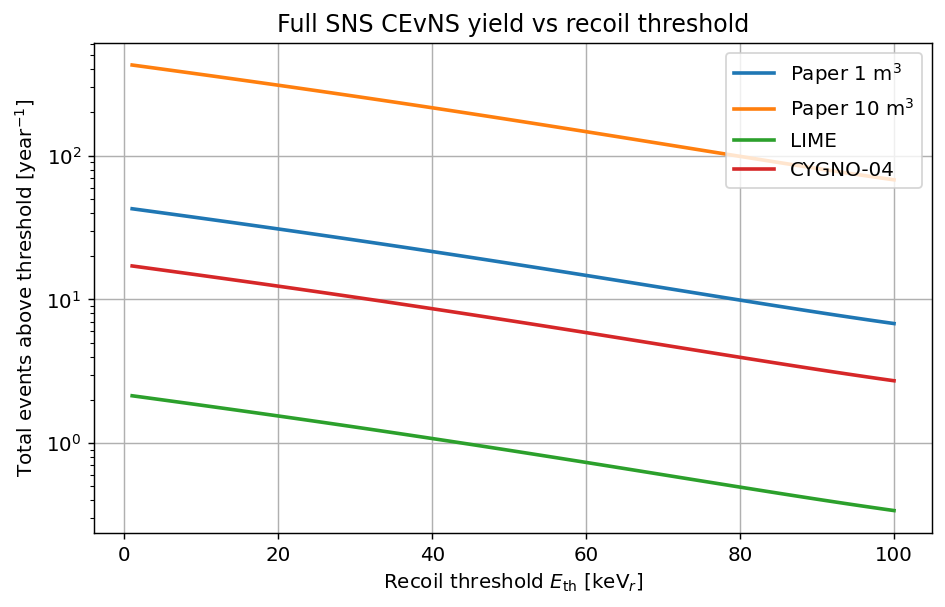

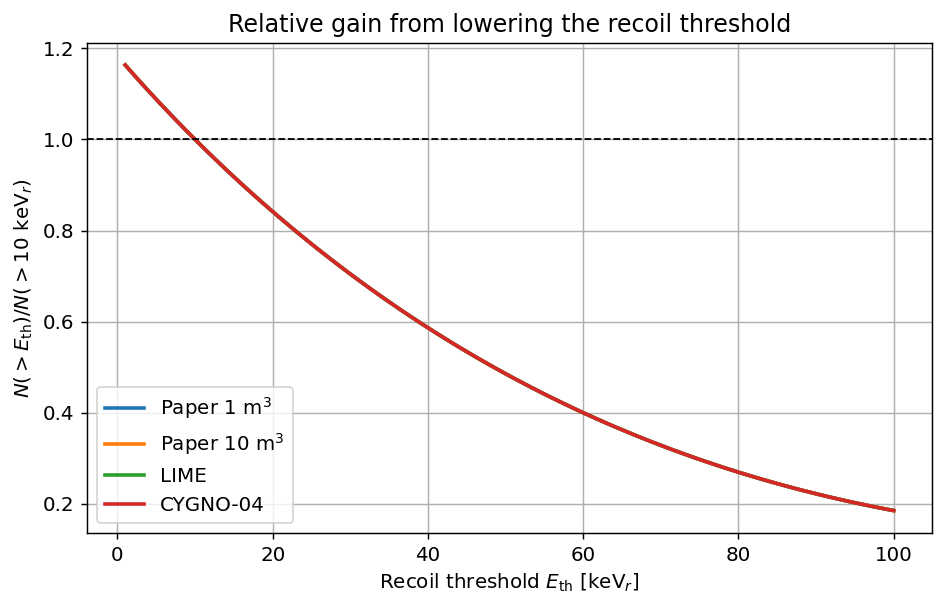

In [60]:
# Cell 7.2
# Total CEvNS events above threshold vs recoil threshold
# for the four detector configurations, using the full SNS source.
#
# This is useful to quantify how much is really gained by lowering
# the recoil threshold from 10 keV_r toward 1 keV_r.

Eth_grid = np.linspace(1.0, 100.0, 120)
detector_order = ["Paper 1 m$^3$", "Paper 10 m$^3$", "LIME", "CYGNO-04"]

total_curves = {}
ratio_to_10keV = {}

for det_name in detector_order:
    y = []
    for Eth in Eth_grid:
        counts = integrated_counts_all_targets(
            Eth,
            source="SNS",
            detector_name=det_name
        )
        y.append(counts["Total"])
    total_curves[det_name] = np.array(y)

    # normalize to the total above 10 keV_r
    counts_10 = integrated_counts_all_targets(
        10.0,
        source="SNS",
        detector_name=det_name
    )["Total"]
    ratio_to_10keV[det_name] = np.array(y) / counts_10

# Print a compact comparison table
rows = []
for det_name in detector_order:
    n1 = integrated_counts_all_targets(1.0, source="SNS", detector_name=det_name)["Total"]
    n5 = integrated_counts_all_targets(5.0, source="SNS", detector_name=det_name)["Total"]
    n10 = integrated_counts_all_targets(10.0, source="SNS", detector_name=det_name)["Total"]
    n20 = integrated_counts_all_targets(20.0, source="SNS", detector_name=det_name)["Total"]

    rows.append({
        "Detector": det_name,
        "N(>1 keV_r) / y": n1,
        "N(>5 keV_r) / y": n5,
        "N(>10 keV_r) / y": n10,
        "N(>20 keV_r) / y": n20,
        "Gain 1 keV / 10 keV": n1 / n10,
    })

threshold_df = pd.DataFrame(rows)
print("Full SNS CEvNS totals vs threshold")
print(threshold_df.to_string(index=False))

# Plot 1: absolute cumulative counts
plt.figure(figsize=(7.4, 4.8))
for det_name in detector_order:
    plt.plot(Eth_grid, total_curves[det_name], lw=2, label=det_name)

plt.yscale("log")
plt.xlabel(r"Recoil threshold $E_{\rm th}$ [keV$_r$]")
plt.ylabel("Total events above threshold [year$^{-1}$]")
plt.title("Full SNS CEvNS yield vs recoil threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: normalized to the 10 keV_r benchmark
plt.figure(figsize=(7.4, 4.8))
for det_name in detector_order:
    plt.plot(Eth_grid, ratio_to_10keV[det_name], lw=2, label=det_name)

plt.axhline(1.0, color="black", ls="--", lw=1)
plt.xlabel(r"Recoil threshold $E_{\rm th}$ [keV$_r$]")
plt.ylabel(r"$N(>E_{\rm th}) / N(>10\ \mathrm{keV}_r)$")
plt.title("Relative gain from lowering the recoil threshold")
plt.legend()
plt.tight_layout()
plt.show()

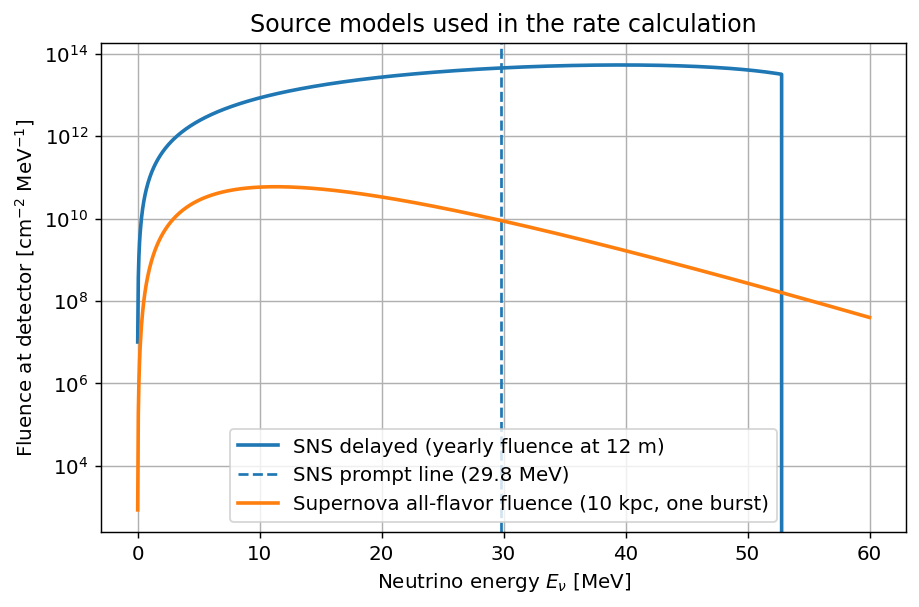

In [33]:
# Cell 8
# Source comparison plot: SNS yearly fluence vs SN burst fluence
# This is not in the paper, but it helps the presentation.

E_plot = np.linspace(0.01, 60.0, 1200)

sns_total_fluence = sns_flux_continuous_per_MeV_per_cm2_per_year(E_plot)
# add prompt line by plotting as a vertical line

sn_mid = sn_fluence_total_per_MeV_per_cm2(E_plot, **sn_scenarios["mid @10 kpc"])

plt.figure(figsize=(7.2, 4.8))
plt.plot(E_plot, sns_total_fluence, lw=2, label="SNS delayed (yearly fluence at 12 m)")
plt.axvline(E_prompt_MeV, color="C0", ls="--", lw=1.5, label=f"SNS prompt line ({E_prompt_MeV:.1f} MeV)")
plt.plot(E_plot, sn_mid, lw=2, label="Supernova all-flavor fluence (10 kpc, one burst)")

plt.yscale("log")
plt.xlabel(r"Neutrino energy $E_\nu$ [MeV]")
plt.ylabel(r"Fluence at detector [cm$^{-2}$ MeV$^{-1}$]")
plt.title("Source models used in the rate calculation")
plt.legend()
plt.tight_layout()
plt.show()

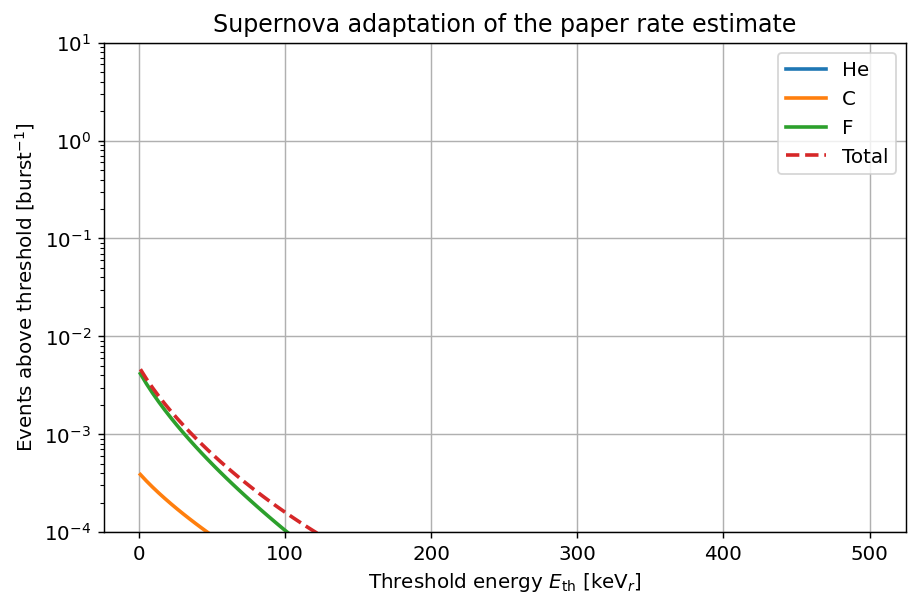

In [50]:
# Cell 9
# Supernova adaptation:
# threshold scan in the same 1 m^3 paper detector, but for one SN burst

sn_threshold_curves = {t: [] for t in ["He", "C", "F", "Total"]}

for Eth in Eth_grid:
    counts = integrated_counts_all_targets(
        Eth,
        source="SN",
        detector_name="Paper 1 m$^3$",
        sn_params=sn_scenarios["mid @10 kpc"]
    )
    for key in sn_threshold_curves:
        sn_threshold_curves[key].append(counts[key])

plt.figure(figsize=(7.2, 4.8))
for key, ls in zip(["He", "C", "F", "Total"], ["-", "-", "-", "--"]):
    plt.plot(Eth_grid, sn_threshold_curves[key], lw=2, ls=ls, label=key)

plt.yscale("log")
plt.xlabel(r"Threshold energy $E_{\rm th}$ [keV$_r$]")
plt.ylabel("Events above threshold [burst$^{-1}$]")
plt.title("Supernova adaptation of the paper rate estimate")
plt.legend()
plt.ylim(1e-4, 1e1)
plt.tight_layout()
plt.show()

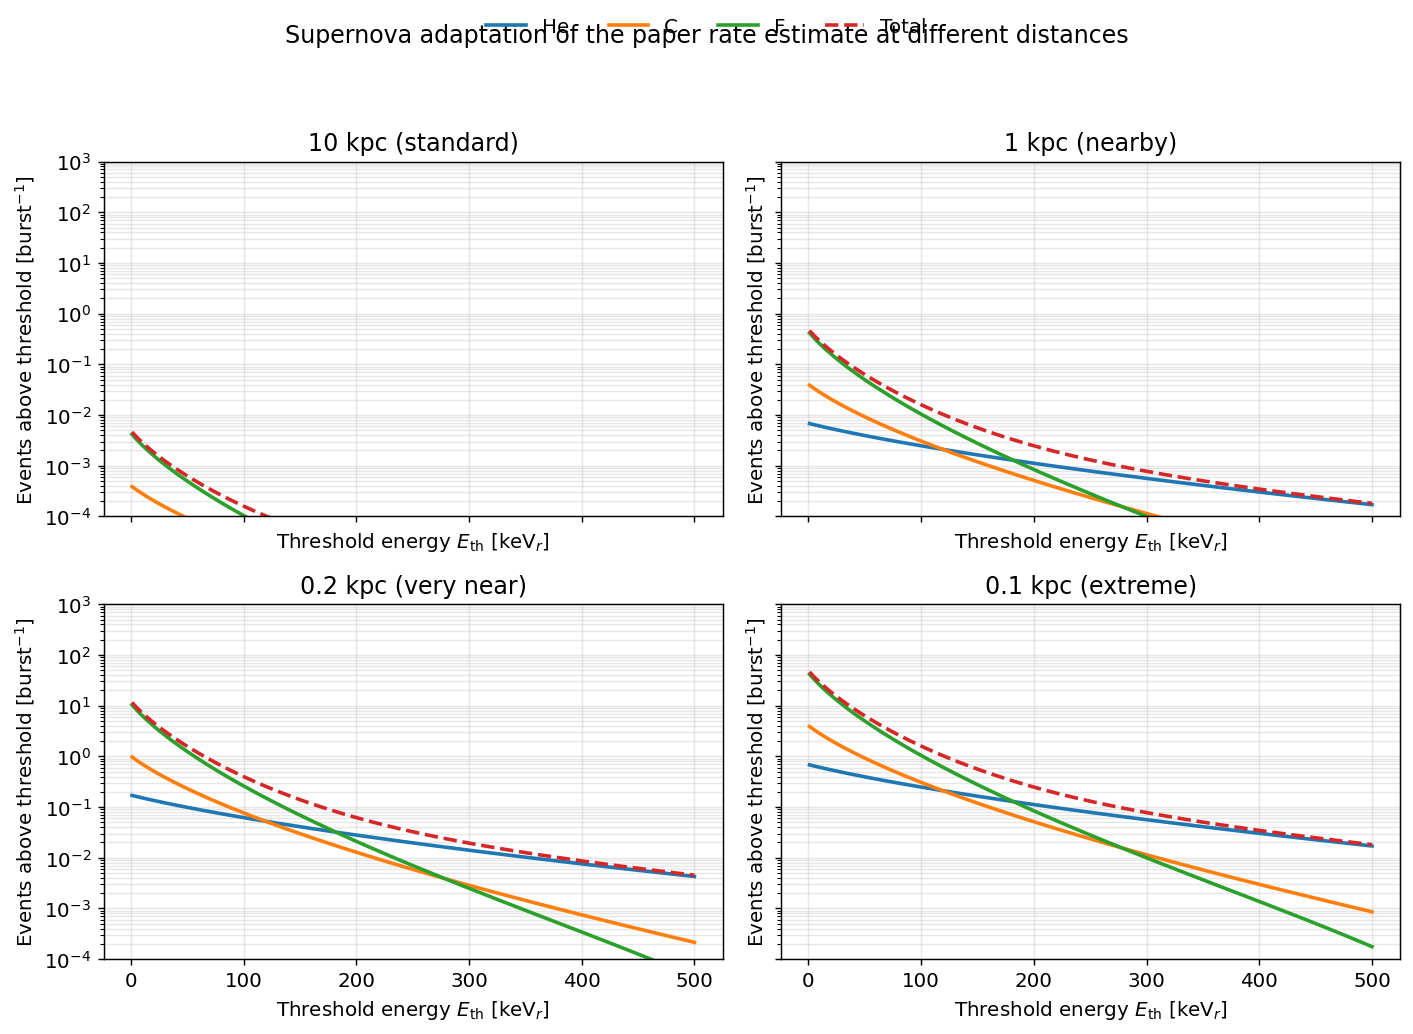

Paper 1 m^3 detector: supernova CEvNS events above 10 keV_r
 Distance [kpc]               Label  He / burst (>10 keV_r)  C / burst (>10 keV_r)  F / burst (>10 keV_r)  Total / burst (>10 keV_r)
           10.0   10 kpc (standard)                0.000061               0.000282               0.002547                   0.002890
            1.0      1 kpc (nearby)                0.006078               0.028209               0.254743                   0.289030
            0.2 0.2 kpc (very near)                0.151945               0.705230               6.368566                   7.225740
            0.1   0.1 kpc (extreme)                0.607780               2.820919              25.474262                  28.902962


In [52]:
# Cell 9.5
# Supernova threshold scan in the paper 1 m^3 detector
# for four source distances:
# - 10 kpc   : standard Galactic benchmark
# - 1 kpc    : nearby Galactic
# - 0.2 kpc  : very nearby / Betelgeuse-like stress test
# - 0.1 kpc  : extreme close-by case (optional stress test)

sn_distance_scenarios = {
    "10 kpc (standard)": 10.0,
    "1 kpc (nearby)": 1.0,
    "0.2 kpc (very near)": 0.2,
    "0.1 kpc (extreme)": 0.1,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.flatten()

summary_rows = []

for ax, (label, Dkpc) in zip(axes, sn_distance_scenarios.items()):
    # Start from the mid spectrum and only change the distance
    pars = dict(sn_scenarios["mid @10 kpc"])
    pars["D_kpc"] = Dkpc

    curves = {t: [] for t in ["He", "C", "F", "Total"]}

    for Eth in Eth_grid:
        counts = integrated_counts_all_targets(
            Eth,
            source="SN",
            detector_name="Paper 1 m$^3$",
            sn_params=pars
        )
        for key in curves:
            curves[key].append(counts[key])

    # Plot per target + total
    for key, ls in zip(["He", "C", "F", "Total"], ["-", "-", "-", "--"]):
        ax.plot(Eth_grid, curves[key], lw=2, ls=ls, label=key)

    ax.set_yscale("log")
    ax.set_title(label)
    ax.set_xlabel(r"Threshold energy $E_{\rm th}$ [keV$_r$]")
    ax.set_ylabel("Events above threshold [burst$^{-1}$]")
    ax.set_ylim(1e-4, 1e3)
    ax.grid(True, which="both", alpha=0.3)

    # Save summary numbers at 10 keV threshold
    counts_10 = integrated_counts_all_targets(
        10.0,
        source="SN",
        detector_name="Paper 1 m$^3$",
        sn_params=pars
    )
    summary_rows.append({
        "Distance [kpc]": Dkpc,
        "Label": label,
        "He / burst (>10 keV_r)": counts_10["He"],
        "C / burst (>10 keV_r)": counts_10["C"],
        "F / burst (>10 keV_r)": counts_10["F"],
        "Total / burst (>10 keV_r)": counts_10["Total"],
    })

# One legend for all panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

fig.suptitle("Supernova adaptation of the paper rate estimate at different distances", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

sn_distance_df = pd.DataFrame(summary_rows)
print("Paper 1 m^3 detector: supernova CEvNS events above 10 keV_r")
print(sn_distance_df.to_string(index=False))

In [51]:
# Cell 10
# Main number table:
# SNS events/year and SN events/burst for the four detector cases

rows = []
for det_name in detectors:
    sns_counts = integrated_counts_all_targets(10.0, source="SNS", detector_name=det_name)
    sn_counts_mid = integrated_counts_all_targets(
        10.0, source="SN", detector_name=det_name, sn_params=sn_scenarios["mid @10 kpc"]
    )
    rows.append({
        "Detector": det_name,
        "Volume [m^3]": detectors[det_name]["volume_m3"],
        "SNS He / y": sns_counts["He"],
        "SNS C / y": sns_counts["C"],
        "SNS F / y": sns_counts["F"],
        "SNS total / y": sns_counts["Total"],
        "SN(10 kpc) He / burst": sn_counts_mid["He"],
        "SN(10 kpc) C / burst": sn_counts_mid["C"],
        "SN(10 kpc) F / burst": sn_counts_mid["F"],
        "SN(10 kpc) total / burst": sn_counts_mid["Total"],
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

      Detector  Volume [m^3]  SNS He / y  SNS C / y  SNS F / y  SNS total / y  SN(10 kpc) He / burst  SN(10 kpc) C / burst  SN(10 kpc) F / burst  SN(10 kpc) total / burst
 Paper 1 m$^3$          1.00    0.619545   3.274223  32.862595      36.756364               0.000061              0.000282              0.002547                  0.002890
Paper 10 m$^3$         10.00    6.195451  32.742234 328.625950     367.563635               0.000608              0.002821              0.025474                  0.028903
          LIME          0.05    0.030977   0.163711   1.643130       1.837818               0.000003              0.000014              0.000127                  0.000145
      CYGNO-04          0.40    0.247818   1.309689  13.145038      14.702545               0.000024              0.000113              0.001019                  0.001156


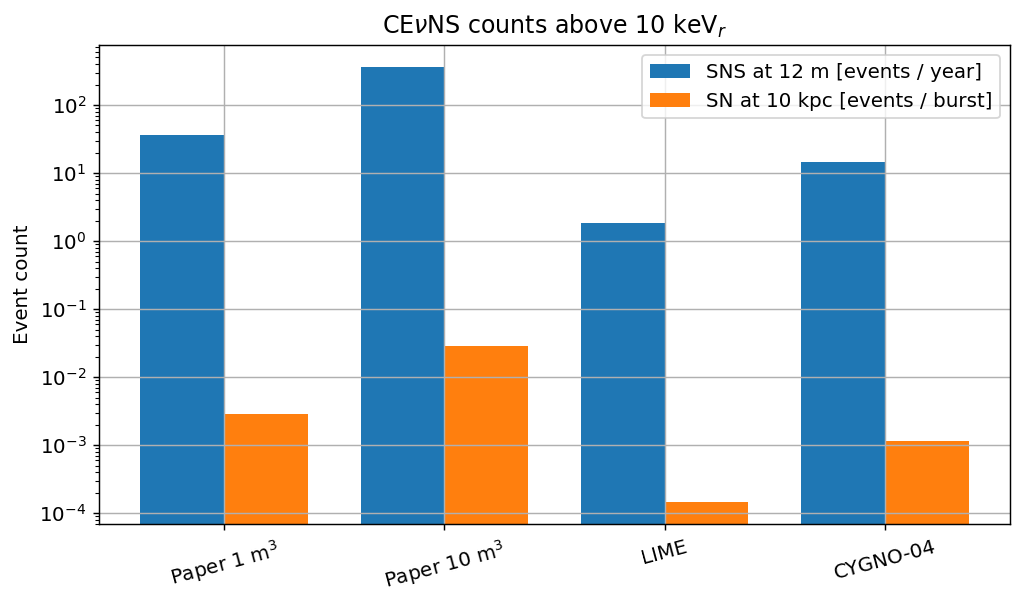

In [36]:
# Cell 11
# Presentation plot:
# grouped bars for SNS and SN in the four detector cases

det_names = list(detectors.keys())
sns_totals = [
    integrated_counts_all_targets(10.0, source="SNS", detector_name=d)["Total"]
    for d in det_names
]
sn_totals = [
    integrated_counts_all_targets(10.0, source="SN", detector_name=d, sn_params=sn_scenarios["mid @10 kpc"])["Total"]
    for d in det_names
]

x = np.arange(len(det_names))
w = 0.38

plt.figure(figsize=(8.0, 4.8))
plt.bar(x - w/2, sns_totals, width=w, label="SNS at 12 m [events / year]")
plt.bar(x + w/2, sn_totals, width=w, label="SN at 10 kpc [events / burst]")

plt.yscale("log")
plt.xticks(x, det_names, rotation=15)
plt.ylabel("Event count")
plt.title(r"CE$\nu$NS counts above 10 keV$_r$")
plt.legend()
plt.tight_layout()
plt.show()

SN spectral scenarios for CYGNO-04
    Scenario  <E_nue> [MeV]  <E_anue> [MeV]  <E_nux> [MeV]  CYGNO-04 events / burst above 10 keV_r
soft @10 kpc           12.0            12.0           15.0                                0.000956
 mid @10 kpc           13.5            13.5           16.5                                0.001156
hard @10 kpc           15.0            15.0           18.0                                0.001353


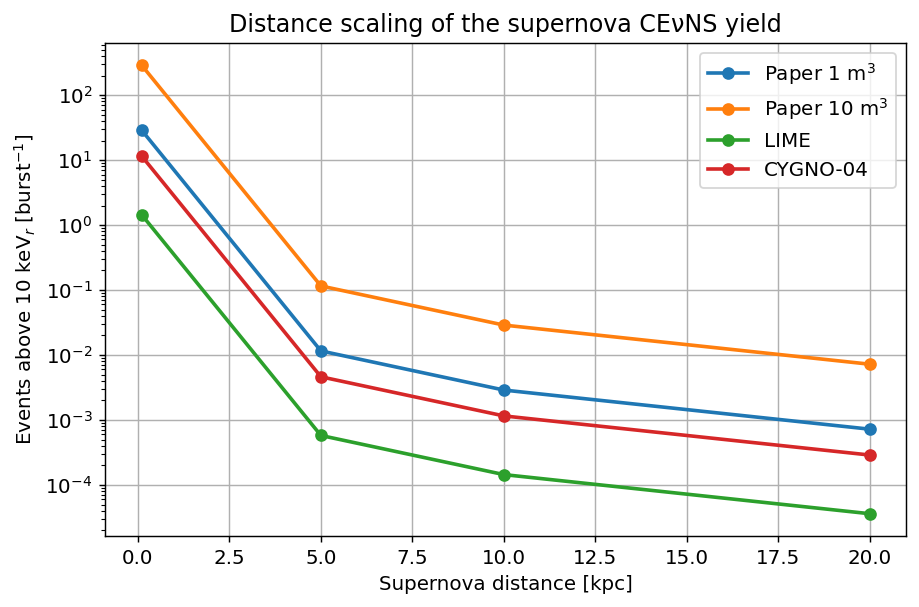

In [37]:
# Cell 12
# Supernova scenario study:
# realistic benchmark list from the literature ranges for average energies,
# and a distance scan at fixed spectrum.

# (a) Spectral benchmark scan at 10 kpc
rows = []
for scen_name, pars in sn_scenarios.items():
    total = integrated_counts_all_targets(
        10.0,
        source="SN",
        detector_name="CYGNO-04",
        sn_params=pars
    )["Total"]
    rows.append({
        "Scenario": scen_name,
        "<E_nue> [MeV]": pars["Eavg_nue"],
        "<E_anue> [MeV]": pars["Eavg_anue"],
        "<E_nux> [MeV]": pars["Eavg_nux"],
        "CYGNO-04 events / burst above 10 keV_r": total,
    })

scenario_df = pd.DataFrame(rows)
print("SN spectral scenarios for CYGNO-04")
print(scenario_df.to_string(index=False))

# (b) Distance scan for all detectors, fixed 'mid' spectrum
plt.figure(figsize=(7.2, 4.8))
for det_name in det_names:
    y = []
    for D in sn_distance_list_kpc:
        pars = dict(sn_scenarios["mid @10 kpc"])
        pars["D_kpc"] = D
        total = integrated_counts_all_targets(
            10.0,
            source="SN",
            detector_name=det_name,
            sn_params=pars
        )["Total"]
        y.append(total)
    plt.plot(sn_distance_list_kpc, y, marker="o", lw=2, label=det_name)

plt.yscale("log")
plt.xlabel("Supernova distance [kpc]")
plt.ylabel(r"Events above 10 keV$_r$ [burst$^{-1}$]")
plt.title("Distance scaling of the supernova CEνNS yield")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# Cell 13
# Optional: lower-threshold study
# This is useful because supernova recoils are much softer than SNS recoils.

for Eth in [10.0, 5.0, 2.0, 1.0]:
    row = {"Threshold [keV_r]": Eth}
    for det_name in det_names:
        row[det_name] = integrated_counts_all_targets(
            Eth,
            source="SN",
            detector_name=det_name,
            sn_params=sn_scenarios["mid @10 kpc"]
        )["Total"]
    print(row)

{'Threshold [keV_r]': 10.0, 'Paper 1 m$^3$': 0.0028902961502616036, 'Paper 10 m$^3$': 0.028902961502616037, 'LIME': 0.0001445148075130802, 'CYGNO-04': 0.0011561184601046417}
{'Threshold [keV_r]': 5.0, 'Paper 1 m$^3$': 0.0037059822671635274, 'Paper 10 m$^3$': 0.037059822671635274, 'LIME': 0.00018529911335817643, 'CYGNO-04': 0.0014823929068654115}
{'Threshold [keV_r]': 2.0, 'Paper 1 m$^3$': 0.0043603217348779765, 'Paper 10 m$^3$': 0.04360321734877978, 'LIME': 0.00021801608674389887, 'CYGNO-04': 0.001744128693951191}
{'Threshold [keV_r]': 1.0, 'Paper 1 m$^3$': 0.004617360186726555, 'Paper 10 m$^3$': 0.046173601867265546, 'LIME': 0.00023086800933632784, 'CYGNO-04': 0.0018469440746906227}


Mean angle      = 57.65 deg
Std. deviation  = 15.78 deg
FWHM            = 42.50 deg
Half-max range  = [38.55, 81.05] deg


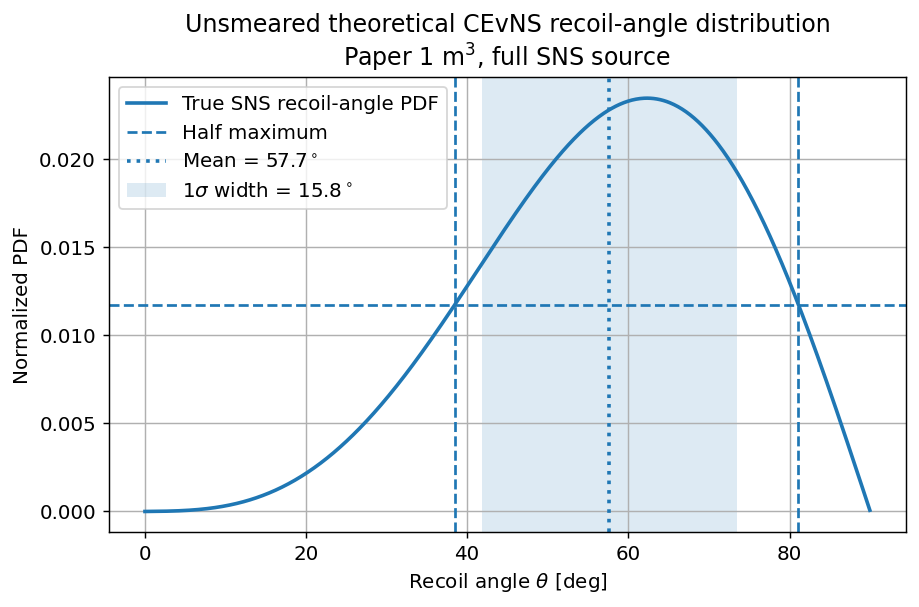

In [64]:
# Cell 6.5
# Unsmeared theoretical recoil-angle distribution for the paper 1 m^3 detector
# Built from the same SNS source + CEvNS cross section already used in the notebook.
#
# It computes dN/dtheta for the TRUE recoil-angle distribution (no detector smearing),
# sums over He, C, F and over prompt + delayed SNS components,
# then plots the PDF and marks the standard deviation and FWHM.

import numpy as np
import matplotlib.pyplot as plt

# ---- helper: recoil energy as a function of angle and neutrino energy ----
# From the paper kinematics:
# cos(theta) = ((E_nu + m_N)/E_nu) * sqrt(E_r / (E_r + 2 m_N))
# Invert to obtain E_r(theta, E_nu).
def Er_from_theta(theta_rad, E_nu_MeV, mN_MeV):
    c = np.cos(theta_rad)
    a = (E_nu_MeV / (E_nu_MeV + mN_MeV))**2
    k = a * c**2
    # physical domain gives k < 1
    return 2.0 * mN_MeV * k / (1.0 - k)  # MeV

def dEr_dtheta_abs(theta_rad, E_nu_MeV, mN_MeV):
    # numerical derivative is fine for a simple presentation plot
    dth = 1e-5
    th1 = np.clip(theta_rad - dth, 1e-6, np.pi/2 - 1e-6)
    th2 = np.clip(theta_rad + dth, 1e-6, np.pi/2 - 1e-6)
    Er1 = Er_from_theta(th1, E_nu_MeV, mN_MeV)
    Er2 = Er_from_theta(th2, E_nu_MeV, mN_MeV)
    return np.abs((Er2 - Er1) / (th2 - th1))

# ---- angle grid ----
theta_deg = np.linspace(0.05, 89.95, 900)
theta_rad = np.deg2rad(theta_deg)

# ---- neutrino-energy grid for delayed components ----
E_nu_grid = np.linspace(0.01, 80.0, 2500)

# total unsmeared angular spectrum dN/dtheta [events / year / rad]
dNdtheta_total = np.zeros_like(theta_rad)

for tname, tinfo in targets.items():
    A = tinfo["A"]
    Z = tinfo["Z"]
    R_rms_fm = tinfo["R_rms_fm"]
    mN = A * amu_MeV
    N_targets = target_nuclei_count(detectors["Paper 1 m$^3$"]["masses_kg"][tname], A)

    # ----- delayed SNS components -----
    phi_delayed = sns_flux_continuous_per_MeV_per_cm2_per_year(E_nu_grid)

    # Build 2D arrays: theta x E_nu
    TH, ENU = np.meshgrid(theta_rad, E_nu_grid, indexing="ij")

    Er_MeV = Er_from_theta(TH, ENU, mN)
    Er_keV = 1e3 * Er_MeV
    jac = dEr_dtheta_abs(TH, ENU, mN)  # MeV / rad

    dsig = d_sigma_dEr_cm2_per_MeV(
        ENU,
        Er_keV,
        A=A, Z=Z, R_rms_fm=R_rms_fm
    )

    # dN/dtheta = N_T ∫ phi(E_nu) [dσ/dE_r] |dE_r/dtheta| dE_nu
    dNdtheta_delayed = N_targets * np.trapz(dsig * jac * phi_delayed[None, :], E_nu_grid, axis=1)

    # ----- prompt SNS line at 29.8 MeV -----
    Er_prompt_MeV = Er_from_theta(theta_rad, E_prompt_MeV, mN)
    Er_prompt_keV = 1e3 * Er_prompt_MeV
    jac_prompt = dEr_dtheta_abs(theta_rad, E_prompt_MeV, mN)

    dsig_prompt = d_sigma_dEr_cm2_per_MeV(
        np.full_like(theta_rad, E_prompt_MeV),
        Er_prompt_keV,
        A=A, Z=Z, R_rms_fm=R_rms_fm
    )

    dNdtheta_prompt = (
        N_targets
        * sns_prompt_line_fluence_per_cm2_per_year()
        * dsig_prompt
        * jac_prompt
    )

    dNdtheta_total += dNdtheta_delayed + dNdtheta_prompt

# ---- normalize to a PDF in theta ----
pdf_theta = dNdtheta_total / np.trapz(dNdtheta_total, theta_deg)

# ---- summary numbers: mean, std, FWHM ----
mean_theta = np.trapz(theta_deg * pdf_theta, theta_deg)
std_theta = np.sqrt(np.trapz((theta_deg - mean_theta)**2 * pdf_theta, theta_deg))

peak = pdf_theta.max()
halfmax = 0.5 * peak
above = np.where(pdf_theta >= halfmax)[0]
theta_left = theta_deg[above[0]]
theta_right = theta_deg[above[-1]]
fwhm = theta_right - theta_left

print(f"Mean angle      = {mean_theta:.2f} deg")
print(f"Std. deviation  = {std_theta:.2f} deg")
print(f"FWHM            = {fwhm:.2f} deg")
print(f"Half-max range  = [{theta_left:.2f}, {theta_right:.2f}] deg")

# ---- plot ----
plt.figure(figsize=(7.2, 4.8))
plt.plot(theta_deg, pdf_theta, lw=2, label="True SNS recoil-angle PDF")
plt.axhline(halfmax, ls="--", lw=1.5, label="Half maximum")
plt.axvline(theta_left, ls="--", lw=1.5)
plt.axvline(theta_right, ls="--", lw=1.5)
plt.axvline(mean_theta, ls=":", lw=2, label=fr"Mean = {mean_theta:.1f}$^\circ$")
plt.axvspan(mean_theta - std_theta, mean_theta + std_theta, alpha=0.15,
            label=fr"$1\sigma$ width = {std_theta:.1f}$^\circ$")

plt.xlabel(r"Recoil angle $\theta$ [deg]")
plt.ylabel("Normalized PDF")
plt.title("Unsmeared theoretical CEvNS recoil-angle distribution\nPaper 1 m$^3$, full SNS source")
plt.legend()
plt.tight_layout()
plt.show()

Integral over Er = 1.0000016492073764


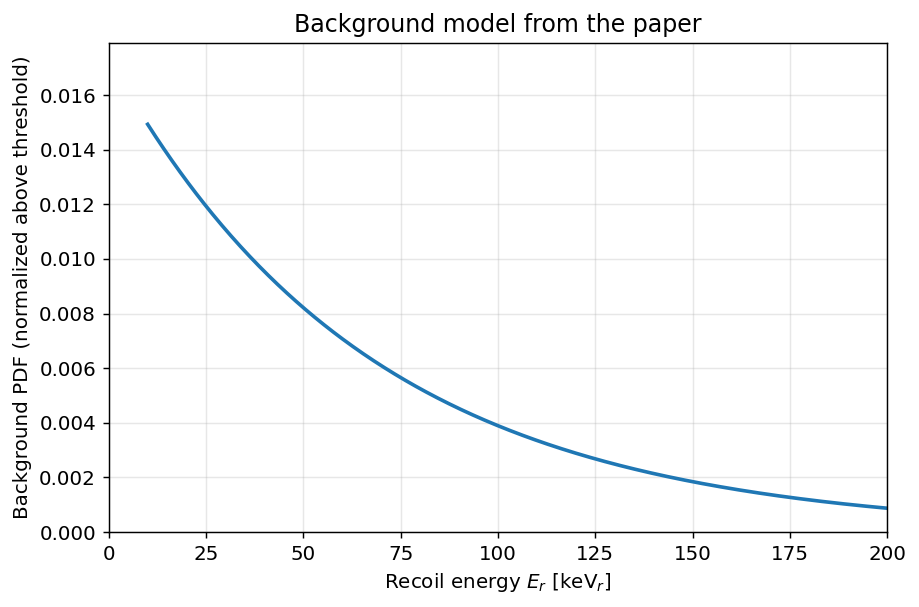

In [71]:
# Check that the paper background model is normalized in recoil energy
import numpy as np

Eth = 10.0   # keV_r
Emax = 1500.0
Ebg = 67.0

Er = np.linspace(Eth, Emax, 5000)
pdf = np.exp(-Er/Ebg) / (Ebg * (np.exp(-Eth/Ebg) - np.exp(-Emax/Ebg)))

print("Integral over Er =", np.trapz(pdf, Er))


#Plot of the background PDF
import matplotlib.pyplot as plt
plt.figure(figsize=(7.2, 4.8))
plt.plot(Er, pdf, lw=2)
plt.xlabel(r"Recoil energy $E_r$ [keV$_r$]")
plt.ylabel("Background PDF (normalized above threshold)")
plt.title("Background model from the paper")
plt.xlim(0, 200)
plt.ylim(0, np.max(pdf)*1.2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()